# Examen final

**Universidad de los Andes - David Cortes Mantilla**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Se realiza el analisis y exploracion de los datos, validando duplicados y separando los datos en train, test y validacion para poder comparar cual modelo elegir.

In [2]:
df = pd.read_csv("genre_dataset.csv")
df.head()

,genre,track_id,artist_name,title,loudness,tempo,time_signature,key,mode,duration,...,var_timbre3,var_timbre4,var_timbre5,var_timbre6,var_timbre7,var_timbre8,var_timbre9,var_timbre10,var_timbre11,var_timbre12
0,classic pop and rock,TRFCOOU128F427AEC0,Blue Oyster Cult,Mes Dames Sarat,-8.697,155.007,1,9,1,246.33424,...,1255.514569,580.030472,598.485223,575.337671,322.068603,321.726029,232.700609,186.805303,181.938688,151.508011
1,classic pop and rock,TRNJTPB128F427AE9F,Blue Oyster Cult,Screams,-10.659,148.462,1,4,0,189.80526,...,2007.653070,1043.474073,585.694981,564.013736,510.177022,400.200186,365.119588,238.099708,197.933757,251.577525
2,classic pop and rock,TRLFJHA128F427AEEA,Blue Oyster Cult,Dance The Night Away,-13.494,112.909,1,10,0,158.19710,...,1204.856777,2736.520024,730.233239,665.203452,535.775111,439.335059,486.822970,265.333860,447.097987,251.880724
3,classic pop and rock,TRCQZAG128F427DB97,Blue Oyster Cult,Debbie Denise,-12.786,117.429,4,7,1,250.22649,...,809.755802,563.908070,492.803819,378.382799,372.875044,231.941957,246.313305,168.400152,85.282462,339.897173
4,classic pop and rock,TRNXMNM128F427DB8C,Blue Oyster Cult,(Don't Fear) The Reaper,-14.093,141.536,4,9,0,307.06893,...,1093.684935,343.556047,889.163314,218.111796,304.862864,178.352161,440.478867,142.669283,81.061326,208.355152


In [3]:
print("Nulos totales:", df.isna().sum().sum())
print("Duplicados (todas las columnas, sin ID):", df.duplicated().sum())

Nulos totales: 0
Duplicados (todas las columnas, sin ID): 0


                          n  proporcion
genre                                  
dance and electronica  4935       0.265
jazz and blues         4334       0.233
soul and reggae        4016       0.216
punk                   3200       0.172
metal                  2103       0.113
Razón mayor/menor: 2.35


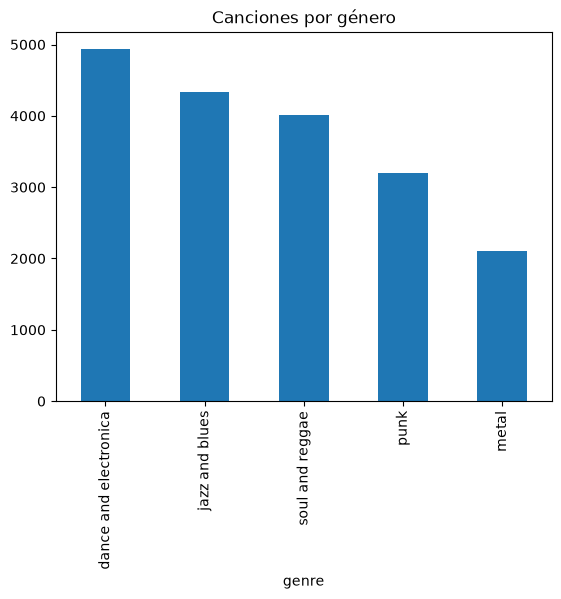

In [4]:
generos = ["dance and electronica", "jazz and blues", "soul and reggae", "punk", "metal"]

df = df[df["genre"].isin(generos)].drop(columns=["track_id", "artist_name", "title"])

balance = df["genre"].value_counts().to_frame("n")
balance["proporcion"] = (balance["n"] / balance["n"].sum()).round(3)

print(balance)
print("Razón mayor/menor:", round(balance["n"].max() / balance["n"].min(), 2))

df["genre"].value_counts().plot(kind="bar", title="Canciones por género");

Las clases presentan un desbalance leve de ~2.35, lo cual no es suficiente como para aplicar una estrategia de balanceo.

In [5]:
df_rest, df_test = train_test_split(df, test_size=0.15, stratify=df["genre"], random_state=42)
df_train, df_val = train_test_split(df_rest, test_size=0.15/0.85, stratify=df_rest["genre"], random_state=42)

## Analisis con modelo de regresion lineal
De modelo base para comparar elegi un modelo de regresion lineal lo cual dara una idea si otro modelo podra dar mejores resultados para el problema con estos datos.

In [6]:
cols_cat = ["key", "time_signature"]

df_train_log = pd.get_dummies(df_train, columns=cols_cat, drop_first=True, dtype=int)
df_val_log = pd.get_dummies(df_val, columns=cols_cat, drop_first=True, dtype=int).reindex(columns=df_train_log.columns, fill_value=0)
df_test_log = pd.get_dummies(df_test, columns=cols_cat, drop_first=True, dtype=int).reindex(columns=df_train_log.columns, fill_value=0)

X_train, y_train = df_train_log.drop(columns="genre"), df_train_log["genre"]
X_val, y_val = df_val_log.drop(columns="genre"), df_val_log["genre"]
X_test, y_test = df_test_log.drop(columns="genre"), df_test_log["genre"]

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold


cols_num = [c for c in X_train.columns if c.startswith(("avg_timbre", "var_timbre")) or c in ["loudness", "tempo", "duration"]]

transformer = ColumnTransformer([("esc", StandardScaler(), cols_num)], remainder="passthrough")

pipe = Pipeline([("transformer", transformer), ("clf", LogisticRegression(max_iter=2000))])

grid = GridSearchCV(
    pipe,
    param_grid={"clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
                "clf__class_weight": [None, "balanced"]},
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    return_train_score=True, n_jobs=-1
).fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("macro-F1 CV:", round(grid.best_score_, 4))

Mejores parámetros: {'clf__C': 10, 'clf__class_weight': None}
macro-F1 CV: 0.669


In [8]:
from sklearn.metrics import f1_score, classification_report

mejor_log = grid.best_estimator_
pred_val = mejor_log.predict(X_val)
print("macro-F1 val:", round(f1_score(y_val, pred_val, average="macro"), 4))
print(classification_report(y_val, pred_val))

macro-F1 val: 0.6722
                       precision    recall  f1-score   support

dance and electronica       0.65      0.62      0.63       741
       jazz and blues       0.68      0.69      0.69       650
                metal       0.73      0.75      0.74       315
                 punk       0.67      0.68      0.67       480
      soul and reggae       0.63      0.63      0.63       603

             accuracy                           0.66      2789
            macro avg       0.67      0.67      0.67      2789
         weighted avg       0.66      0.66      0.66      2789



## Analisis con modelo XGBoost
Se elige el modelo XGBoost para validar si da mejores resultados que el modelo base.

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder().fit(df_train["genre"])

X_train_x, y_train_x = df_train.drop(columns="genre"), le.transform(df_train["genre"])
X_val_x, y_val_x = df_val.drop(columns="genre"), le.transform(df_val["genre"])
X_test_x, y_test_x = df_test.drop(columns="genre"), le.transform(df_test["genre"])

print(dict(enumerate(le.classes_)))

{0: 'dance and electronica', 1: 'jazz and blues', 2: 'metal', 3: 'punk', 4: 'soul and reggae'}


In [10]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

xgb = XGBClassifier(objective="multi:softprob", tree_method="hist",
                    n_estimators=300, random_state=42, n_jobs=1)

param_dist = {
    "max_depth": randint(6, 10),
    "learning_rate": uniform(0.05, 0.15),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.5, 0.5),
    "min_child_weight": randint(1, 15),
    "reg_lambda": uniform(1, 19),
    "reg_alpha": uniform(0, 2),
}

busqueda = RandomizedSearchCV(
    xgb, param_dist, n_iter=30, scoring="f1_macro",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    return_train_score=True, n_jobs=-1, random_state=42, verbose=2
).fit(X_train_x, y_train_x)

print("Mejores parámetros:", busqueda.best_params_)
print("macro-F1 CV:", round(busqueda.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END colsample_bytree=0.6872700594236812, learning_rate=0.19260714596148742, max_depth=8, min_child_weight=8, reg_alpha=1.1973169683940732, reg_lambda=3.964354168406294, subsample=0.662397808134481; total time=  11.7s
[CV] END colsample_bytree=0.6872700594236812, learning_rate=0.19260714596148742, max_depth=8, min_child_weight=8, reg_alpha=1.1973169683940732, reg_lambda=3.964354168406294, subsample=0.662397808134481; total time=  11.8s
[CV] END colsample_bytree=0.6872700594236812, learning_rate=0.19260714596148742, max_depth=8, min_child_weight=8, reg_alpha=1.1973169683940732, reg_lambda=3.964354168406294, subsample=0.662397808134481; total time=  11.2s
[CV] END colsample_bytree=0.6872700594236812, learning_rate=0.19260714596148742, max_depth=8, min_child_weight=8, reg_alpha=1.1973169683940732, reg_lambda=3.964354168406294, subsample=0.662397808134481; total time=  11.3s
[CV] END colsample_bytree=0.6872700594236812, lear

In [11]:
from sklearn.metrics import f1_score, classification_report

mejor_xgb = busqueda.best_estimator_
pred_val_x = mejor_xgb.predict(X_val_x)

print("Mejores parámetros:", busqueda.best_params_)
print("macro-F1 val XGBoost:", round(f1_score(y_val_x, pred_val_x, average="macro"), 4))
print(classification_report(y_val_x, pred_val_x, target_names=le.classes_))

Mejores parámetros: {'colsample_bytree': np.float64(0.6987860105437611), 'learning_rate': np.float64(0.12766270257912202), 'max_depth': 9, 'min_child_weight': 1, 'reg_alpha': np.float64(1.3513802340785614), 'reg_lambda': np.float64(14.96910626557467), 'subsample': np.float64(0.6836286482950855)}
macro-F1 val XGBoost: 0.7386
                       precision    recall  f1-score   support

dance and electronica       0.71      0.74      0.73       741
       jazz and blues       0.76      0.77      0.76       650
                metal       0.78      0.75      0.76       315
                 punk       0.77      0.70      0.73       480
      soul and reggae       0.70      0.72      0.71       603

             accuracy                           0.74      2789
            macro avg       0.74      0.73      0.74      2789
         weighted avg       0.74      0.74      0.74      2789



In [12]:
comparacion = pd.DataFrame({
    "modelo": ["Regresión logística", "XGBoost"],
    "macro-F1 CV": [grid.best_score_, busqueda.best_score_],
    "macro-F1 val": [f1_score(y_val, pred_val, average="macro"),
                     f1_score(y_val_x, pred_val_x, average="macro")],
}).round(4)
comparacion

,modelo,macro-F1 CV,macro-F1 val
0,Regresión logística,0.669,0.6722
1,XGBoost,0.736,0.7386


## Conclusiones

In [14]:
pred_test_x = mejor_xgb.predict(X_test_x)

print("macro-F1 test:", round(f1_score(y_test_x, pred_test_x, average="macro"), 4))
print(classification_report(y_test_x, pred_test_x, target_names=le.classes_))

macro-F1 test: 0.7521
                       precision    recall  f1-score   support

dance and electronica       0.73      0.73      0.73       740
       jazz and blues       0.78      0.79      0.78       650
                metal       0.83      0.74      0.79       316
                 punk       0.78      0.69      0.73       480
      soul and reggae       0.69      0.78      0.74       603

             accuracy                           0.75      2789
            macro avg       0.76      0.75      0.75      2789
         weighted avg       0.75      0.75      0.75      2789



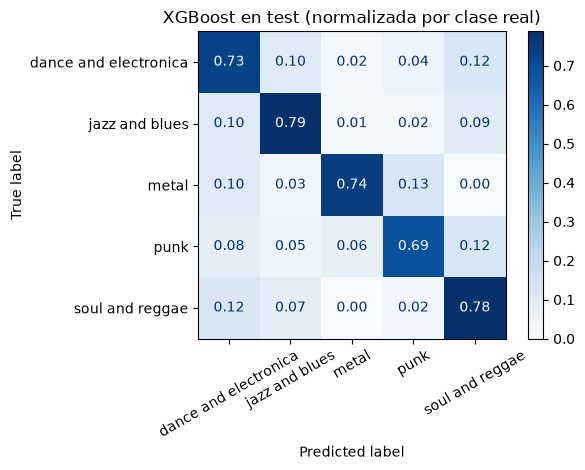

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    le.classes_[y_test_x], le.classes_[pred_test_x],
    normalize="true", values_format=".2f", xticks_rotation=30, cmap="Blues")
plt.title("XGBoost en test (normalizada por clase real)")
plt.tight_layout(); plt.show()

In [15]:
import numpy as np

rng = np.random.default_rng(42)
n = len(y_test_x)
scores = [f1_score(y_test_x[i], pred_test_x[i], average="macro")
          for i in (rng.integers(0, n, n) for _ in range(1000))]

print("IC 95% macro-F1 test:", np.percentile(scores, [2.5, 97.5]).round(4))

IC 95% macro-F1 test: [0.7349 0.7679]
